# Assignment: Numpy and Matplotlib

## Part 1: Creating and Manipulating Arrays

First import numpy and matplotlib

In [1]:
import numpy as np
from matplotlib import pyplot as plt

### 1.1. Create two 2D arrays representing coordinates x, y on the cartesian plan
Both should cover the range (-2, 2) and have 100 points in each direction

In [2]:
x = np.linspace(-2, 2, 100)
y = np.linspace(-2, 2, 100)
X, Y = np.meshgrid(x, y)

### 1.2. Visualize each 2D array using pcolormesh
Use the correct coordiantes for the x and y axes.

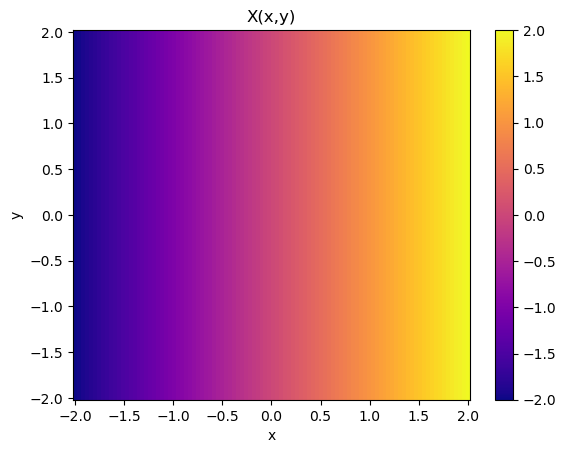

In [3]:
plt.pcolormesh(x, y, X, cmap='plasma')
plt.colorbar()
plt.xlabel("x")
plt.ylabel("y")
plt.title("X(x,y)") 
plt.show()

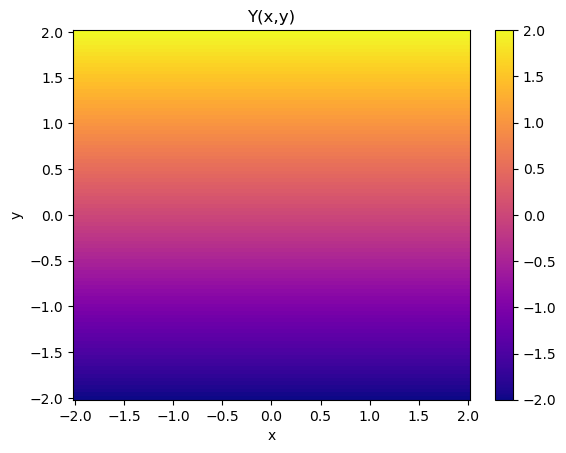

In [4]:
plt.pcolormesh(x, y, Y, cmap='plasma')
plt.colorbar()
plt.xlabel("x")
plt.ylabel("y")
plt.title("Y(x,y)") 
plt.show()

### 1.3 From your cartesian coordinates, create polar coordinates $r$ and $\varphi$
Refer to the wikipedia page for the conversion formula. You will need to use numpy’s arctan2 function. Read its documentation.

In [ ]:
np.arctan2?

In [6]:
r= np.sqrt(X**2 + Y**2)
phi = np.arctan2(Y,X)

### 1.4. Visualize $r$ and $\varphi$ on the 2D $x$ / $y$ plane using pcolormesh

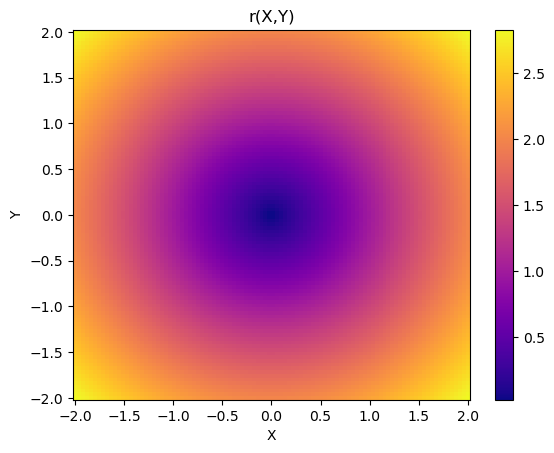

In [7]:
plt.pcolormesh(X, Y, r, cmap='plasma')
plt.colorbar()
plt.xlabel("X")
plt.ylabel("Y")
plt.title("r(X,Y)") 
plt.show()

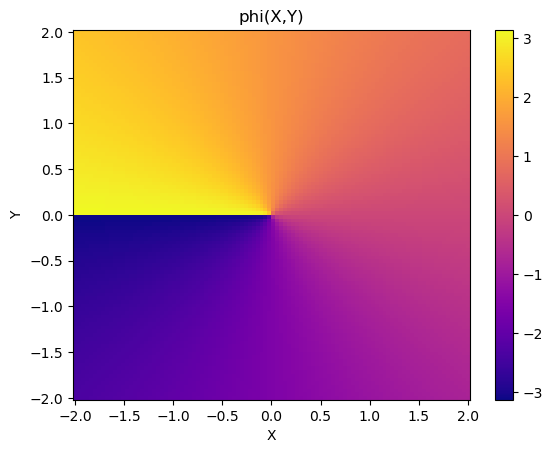

In [8]:
plt.pcolormesh(X, Y, phi, cmap='plasma')
plt.colorbar()
plt.xlabel("X")
plt.ylabel("Y")
plt.title("phi(X,Y)") 
plt.show()

### 1.5 Caclulate the quanity $f = \cos^2(4r) + \sin^2(4\varphi)$
And plot it on the xy$ plane

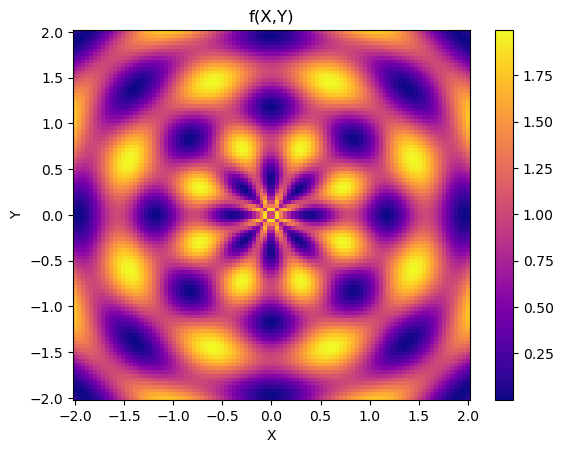

In [9]:
f = np.cos(4*r)**2 + np.sin(4*phi)**2
plt.pcolormesh(X, Y, f, cmap='plasma')
plt.colorbar()
plt.xlabel("X")
plt.ylabel("Y")
plt.title("f(X,Y)") 
plt.show()

## Part 2: Analyze ARGO Data

In this problem, we use real data from ocean profiling floats. ARGO floats are autonomous robotic instruments that collect Temperature, Salinity, and Pressure data from the ocean. ARGO floats collect one “profile” (a set of messurements at different depths or “levels”).  
Each profile has a single latitude, longitude, and date associated with it, in addition to many different levels.  
Let’s start by using pooch to download the data files we need for this exercise. The following code will give you a list of .npy files that you can open in the next step.

In [10]:
import pooch
url = "https://www.ldeo.columbia.edu/~danielmw/float_data.zip"
files = pooch.retrieve(url, processor=pooch.Unzip(), known_hash="2a703c720302c682f1662181d329c9f22f9f10e1539dc2d6082160a469165009")
files

['/home/jb5222/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/date.npy',
 '/home/jb5222/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/T.npy',
 '/home/jb5222/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/S.npy',
 '/home/jb5222/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/P.npy',
 '/home/jb5222/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/levels.npy',
 '/home/jb5222/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/lon.npy',
 '/home/jb5222/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/lat.npy']

### 2.1 Load each data file as a numpy array.
You can use whatever names you want for your arrays, but I recommend  
T: temperature  
S: salinity  
P: pressure  
date: date  
lat: latitude  
lon: longitude  
level: depth level  
Note: you have to actually look at the file name (the items in files) to know which files corresponds to which variable.

In [11]:
T = np.load([f for f in files if 'T.npy' in f][0])
S = np.load([f for f in files if 'S.npy' in f][0])
P = np.load([f for f in files if 'P.npy' in f][0])
date = np.load([f for f in files if 'date.npy' in f][0])
lat = np.load([f for f in files if 'lat.npy' in f][0])
lon = np.load([f for f in files if 'lon.npy' in f][0])
level = np.load([f for f in files if 'levels.npy' in f][0])

### 2.2 Examine the shapes of T, S and P compared to lon, lat, date and level. How do you think they are related?
Based on the shapes, which dimensions do you think are shared among the arrays?

In [13]:
T.shape, S.shape, P.shape

((78, 75), (78, 75), (78, 75))

In [14]:
lon.shape, lat.shape, date.shape, level.shape

((75,), (75,), (75,), (78,))

#### **Answer:**
From the shapes, we know that T, S and P are 2D arrays, whereas lon, lat, date and level are 1D arrays. More specifically, level matches the first dimension of T, S and P, which is 78. In contrast, lon, lat and date matches the second dimension of T, S and P, which is 75.
I think their relationship is that the first dimension provides the depth level and the second dimension provides the specific location and time. For example, T[x, y] is the temperature at depth level[x] for the location (lon[y], lat[y]) measured at date[y].

### 2.3 Make a plot for each column of data in T, S and P (three plots).
The vertical scale should be the levels data. Each plot should have a line for each column of data. It will look messy.

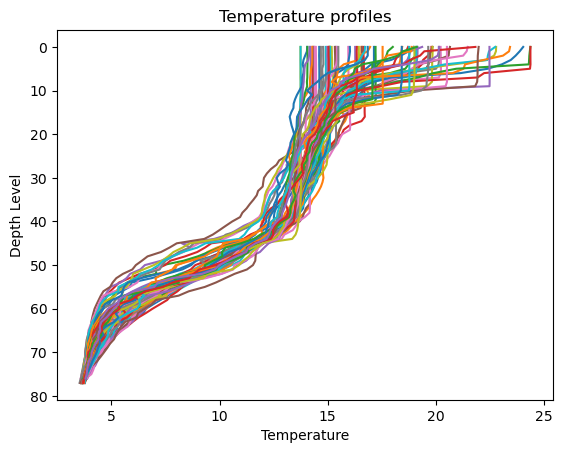

In [15]:
plt.plot(T, level)
plt.gca().invert_yaxis()
plt.xlabel("Temperature")
plt.ylabel("Depth Level")
plt.title("Temperature profiles") 
plt.show()

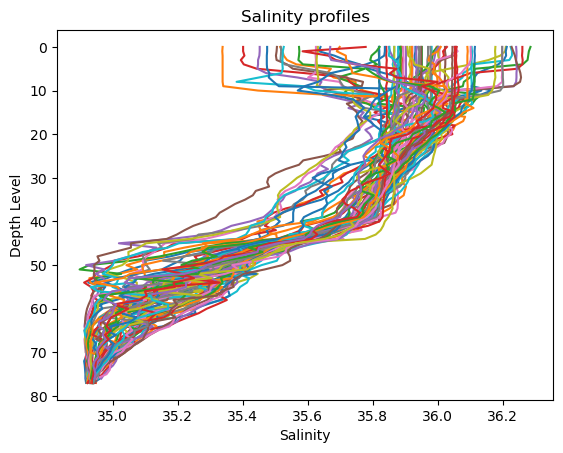

In [16]:
plt.plot(S, level)
plt.gca().invert_yaxis()
plt.xlabel("Salinity")
plt.ylabel("Depth Level")
plt.title("Salinity profiles")
plt.show()

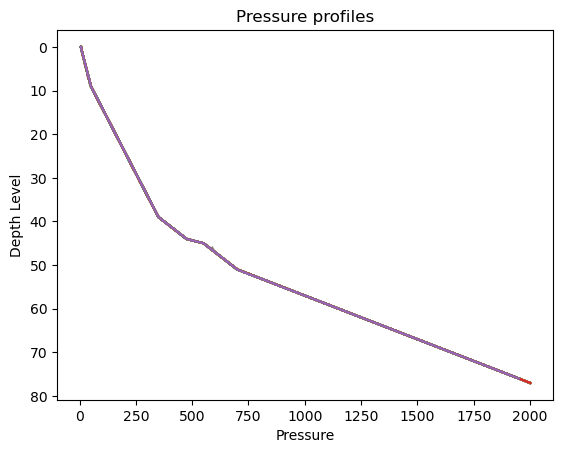

In [17]:
plt.plot(P, level)
plt.gca().invert_yaxis()
plt.xlabel("Pressure")
plt.ylabel("Depth Level")
plt.title("Pressure profiles")
plt.show()

### 2.4 Compute the mean and standard deviation of each of T, S and P at each depth in level.

In [18]:
T_level_mean = np.mean(T, axis=1)
T_level_mean

array([        nan,         nan,         nan,         nan,         nan,
               nan,         nan,         nan,         nan,         nan,
               nan,         nan,         nan,         nan,         nan,
               nan,         nan,         nan,         nan,         nan,
               nan,         nan,         nan,         nan,         nan,
               nan,         nan,         nan,         nan,         nan,
               nan,         nan,         nan,         nan,         nan,
               nan,         nan,         nan,         nan,         nan,
               nan,         nan,         nan,         nan,         nan,
               nan, 10.80430666, 10.49702667, 10.1749066 ,  9.83453334,
        9.48625332,  9.19793334,  8.66010666,  8.12324001,  7.60221333,
        7.15289333,  6.74250667,  6.39543999,  6.04598667,  5.74538665,
        5.48913333,  5.26604001,  5.08768   ,  4.93479998,  4.77769334,
        4.65368   ,  4.54237334,  4.44274664,  4.35933333,      

In [19]:
S_level_mean = np.mean(S, axis=1)
S_level_mean

array([        nan,         nan,         nan,         nan,         nan,
               nan,         nan,         nan,         nan,         nan,
               nan,         nan,         nan,         nan,         nan,
               nan,         nan,         nan,         nan,         nan,
               nan,         nan,         nan,         nan,         nan,
               nan,         nan,         nan,         nan,         nan,
               nan,         nan,         nan,         nan,         nan,
               nan,         nan,         nan,         nan,         nan,
               nan,         nan,         nan,         nan,         nan,
               nan, 35.41392634, 35.3810557 , 35.34845245, 35.31531555,
       35.28392568, 35.26568334, 35.2389473 , 35.21583745, 35.19686081,
       35.18231257, 35.1648436 , 35.15073542, 35.12509338, 35.10155869,
       35.08199799, 35.06317012, 35.0490097 , 35.03678253, 35.02174266,
       35.01135579, 35.00212936, 34.99386297, 34.98810328,      

In [20]:
P_level_mean = np.mean(P, axis=1)
P_level_mean

array([   6.43466671,           nan,           nan,           nan,
                 nan,           nan,           nan,           nan,
                 nan,           nan,           nan,           nan,
                 nan,           nan,           nan,           nan,
                 nan,           nan,           nan,           nan,
                 nan,           nan,           nan,           nan,
                 nan,           nan,           nan,           nan,
                 nan,           nan,           nan,           nan,
                 nan,           nan,           nan,           nan,
                 nan,           nan,           nan,           nan,
                 nan,           nan,           nan,           nan,
                 nan,           nan,  575.68400146,  600.42400716,
        625.30800456,  650.34533773,  675.33333984,  700.37067546,
        750.42400716,  800.36666992,  850.38534017,  900.4613387 ,
        950.45067383, 1000.38534261, 1050.38534668, 1100.45734

### 2.5 Now make three similar plot, but show only the mean T, S and P at each depth. Show error bars on each plot using the standard deviations.

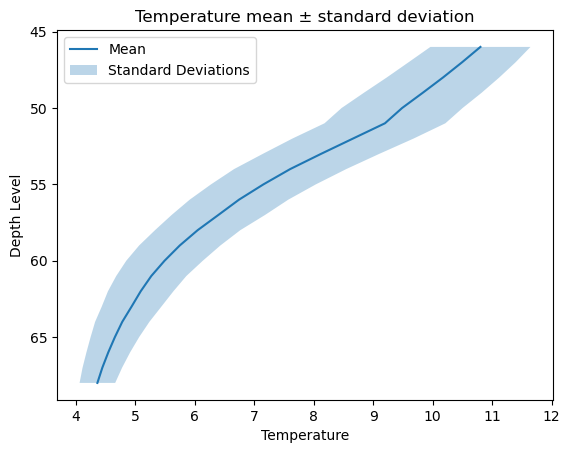

In [21]:
T_level_std = np.std(T, axis=1)

plt.plot(T_level_mean, level, label="Mean")
plt.fill_betweenx(level, T_level_mean - T_level_std, T_level_mean + T_level_std, alpha = 0.3, label="Standard Deviations")
plt.gca().invert_yaxis()
plt.xlabel("Temperature")
plt.ylabel("Depth Level")
plt.title("Temperature mean ± standard deviation") 
plt.legend()
plt.show()

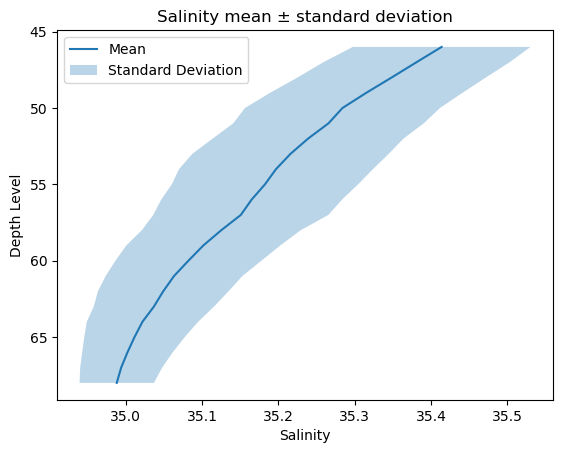

In [22]:
S_level_std = np.std(S, axis=1)

plt.plot(S_level_mean, level, label = 'Mean')
plt.fill_betweenx(level, S_level_mean - S_level_std, S_level_mean + S_level_std, alpha = 0.3, label="Standard Deviation")
plt.gca().invert_yaxis()
plt.xlabel("Salinity")
plt.ylabel("Depth Level")
plt.title("Salinity mean ± standard deviation")
plt.legend()
plt.show()

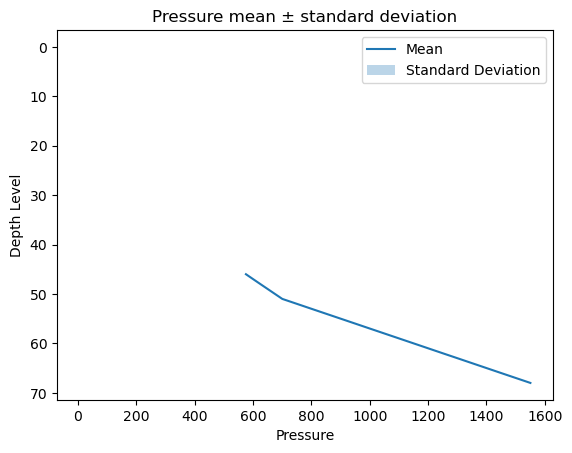

In [23]:
P_level_std = np.std(P, axis=1)

plt.plot(P_level_mean, level, label = 'Mean')
plt.fill_betweenx(level, P_level_mean - P_level_std, P_level_mean + P_level_std, alpha = 0.3, label="Standard Deviation")
plt.gca().invert_yaxis()
plt.xlabel("Pressure")
plt.ylabel("Depth Level")
plt.title("Pressure mean ± standard deviation")
plt.legend()
plt.show()

### 2.6 Account For Missing Data
The profiles contain many missing values. These are indicated by the special “Not a Number” value, or np.nan.

When you take the mean or standard deviation of data with NaNs in it, the entire result becomes NaN. Instead, if you use the special functions np.nanmean and np.nanstd, you tell NumPy to ignore the NaNs.

Recalculate the means and standard deviations as in the previous sections using these functions and plot the results.

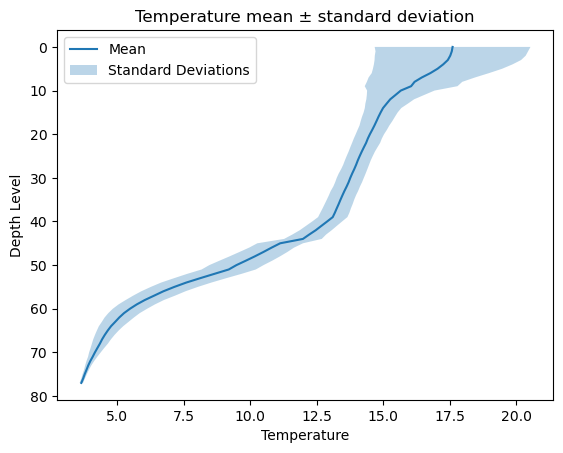

In [24]:
T_level_nanmean = np.nanmean(T, axis=1)
T_level_nanstd = np.nanstd(T, axis=1)

plt.plot(T_level_nanmean, level, label="Mean")
plt.fill_betweenx(level, T_level_nanmean - T_level_nanstd, T_level_nanmean + T_level_nanstd, alpha = 0.3, label="Standard Deviations")
plt.gca().invert_yaxis()
plt.xlabel("Temperature")
plt.ylabel("Depth Level")
plt.title("Temperature mean ± standard deviation") 
plt.legend()
plt.show()

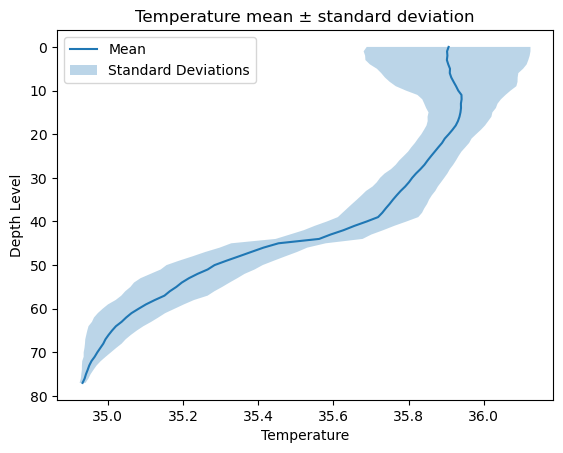

In [25]:
S_level_nanmean = np.nanmean(S, axis=1)
S_level_nanstd = np.nanstd(S, axis=1)

plt.plot(S_level_nanmean, level, label="Mean")
plt.fill_betweenx(level, S_level_nanmean - S_level_nanstd, S_level_nanmean + S_level_nanstd, alpha = 0.3, label="Standard Deviations")
plt.gca().invert_yaxis()
plt.xlabel("Temperature")
plt.ylabel("Depth Level")
plt.title("Temperature mean ± standard deviation") 
plt.legend()
plt.show()

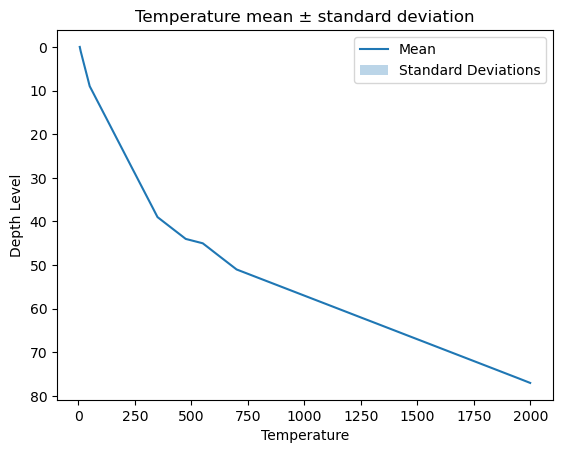

In [26]:
P_level_nanmean = np.nanmean(P, axis=1)
P_level_nanstd = np.nanstd(P, axis=1)

plt.plot(P_level_nanmean, level, label="Mean")
plt.fill_betweenx(level, P_level_nanmean - P_level_nanstd, P_level_nanmean + P_level_nanstd, alpha = 0.3, label="Standard Deviations")
plt.gca().invert_yaxis()
plt.xlabel("Temperature")
plt.ylabel("Depth Level")
plt.title("Temperature mean ± standard deviation") 
plt.legend()
plt.show()

### 2.7 Create a scatter plot of the lon, lat positions of the ARGO float.
Use the plt.scatter function.

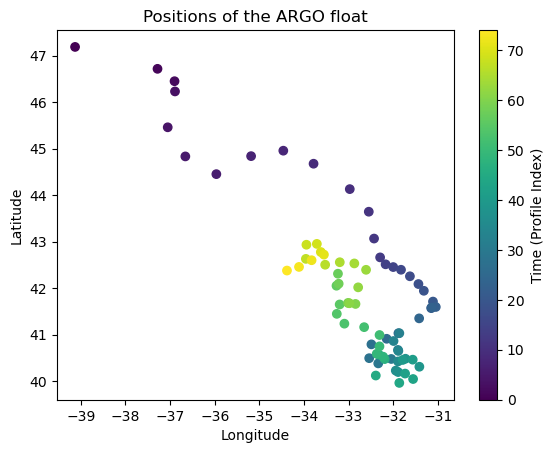

In [27]:
plt.scatter(lon, lat, c=np.arange(len(date)))
plt.colorbar(label="Time (Profile Index)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Positions of the ARGO float") 
plt.show()